# Credit Risk EDA — LendingClub Accepted Loans

Data pulled live from PostgreSQL (`finsight.loans`, loaded via `src/db_connect.py`) — not from the raw CSV.
Explores missingness, key numeric distributions, feature correlations, and default rate by grade/purpose/home-ownership.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from db_connect import get_engine
from eda_utils import plot_distribution, plot_missing_map, plot_correlation_heatmap, sequential_shades

%matplotlib inline
pd.set_option("display.max_columns", 50)

engine = get_engine()
total_loans = pd.read_sql("SELECT COUNT(*) AS n FROM finsight.loans", engine)["n"][0]
print(f"finsight.loans total rows: {total_loans:,}")

finsight.loans total rows: 2,260,668


## Missing values

Sampled ~2% of loans (well above what's needed for a stable missingness read).

Sample size: 47,653 rows


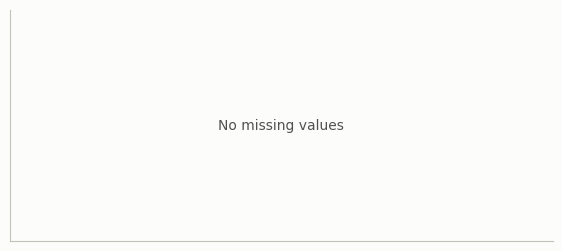

In [2]:
NUMERIC_COLS = ["loan_amount", "funded_amount", "term_months", "interest_rate", "installment",
                "annual_income", "dti", "delinq_2yrs", "fico_range_low", "fico_range_high",
                "open_accounts", "total_accounts", "revol_util"]
CATEGORICAL_COLS = ["grade", "sub_grade", "home_ownership", "verification_status", "purpose",
                     "state", "loan_status", "employment_length"]

sample_df = pd.read_sql(
    f"SELECT {', '.join(NUMERIC_COLS + CATEGORICAL_COLS + ['issue_date'])} "
    f"FROM finsight.loans TABLESAMPLE SYSTEM (2)",
    engine,
)
print(f"Sample size: {len(sample_df):,} rows")

fig, ax = plt.subplots(figsize=(7, 3))
plot_missing_map(sample_df, ax=ax)
plt.show()

## Distributions of key numeric fields

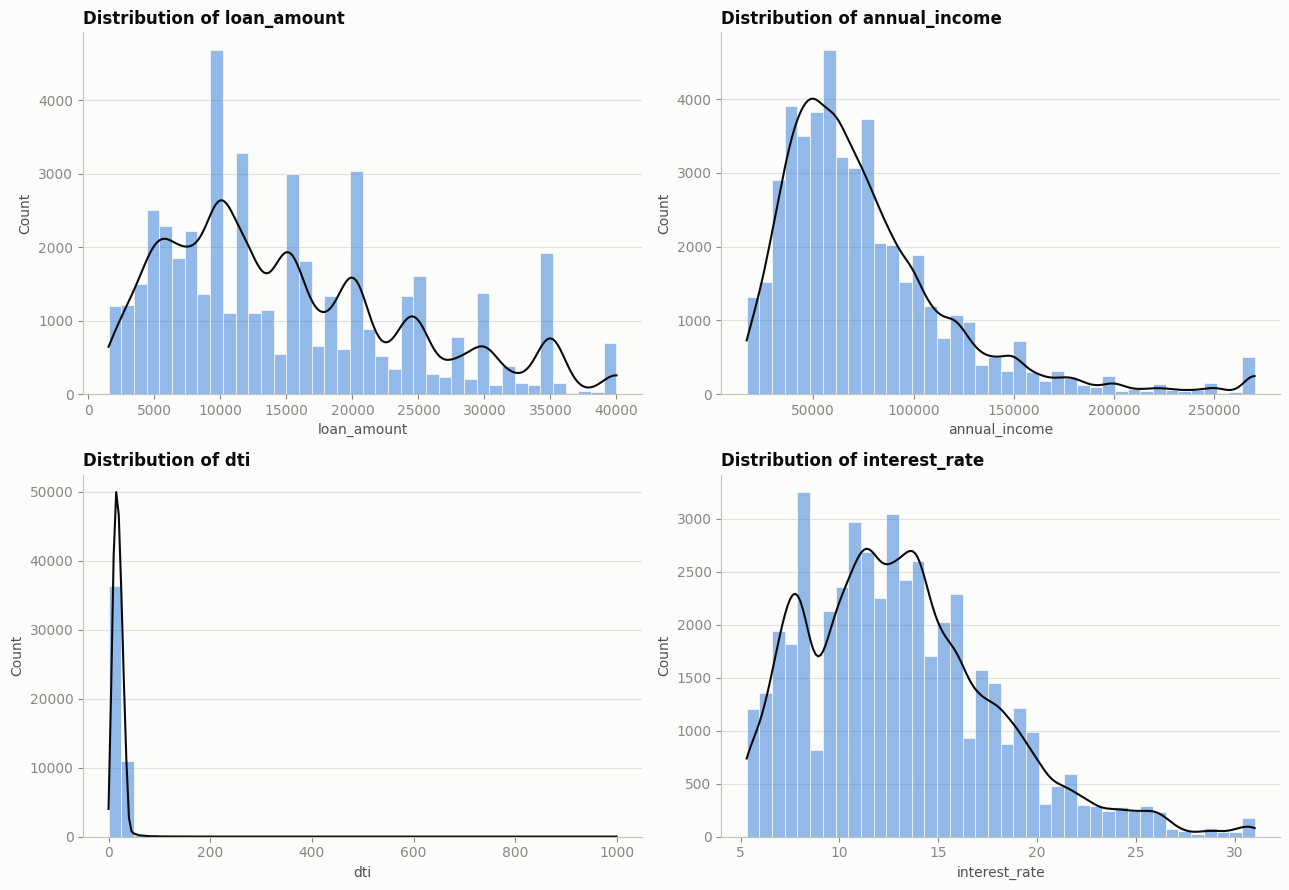

annual_income winsorization cap: $270,000  |  1.01% of sampled loans sit exactly at this cap
loan_amount winsorization cap: $40,000  |  1.43% of sampled loans sit exactly at this cap


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_distribution(sample_df, "loan_amount", ax=axes[0, 0])
plot_distribution(sample_df, "annual_income", ax=axes[0, 1])
plot_distribution(sample_df, "dti", ax=axes[1, 0])
plot_distribution(sample_df, "interest_rate", ax=axes[1, 1])
fig.tight_layout()
plt.show()

income_cap = sample_df["annual_income"].max()
pct_at_cap = (sample_df["annual_income"] == income_cap).mean() * 100
print(f"annual_income winsorization cap: ${income_cap:,.0f}  |  {pct_at_cap:.2f}% of sampled loans sit exactly at this cap")

amount_cap = sample_df["loan_amount"].max()
pct_amount_at_cap = (sample_df["loan_amount"] == amount_cap).mean() * 100
print(f"loan_amount winsorization cap: ${amount_cap:,.0f}  |  {pct_amount_at_cap:.2f}% of sampled loans sit exactly at this cap")

## Correlation heatmap

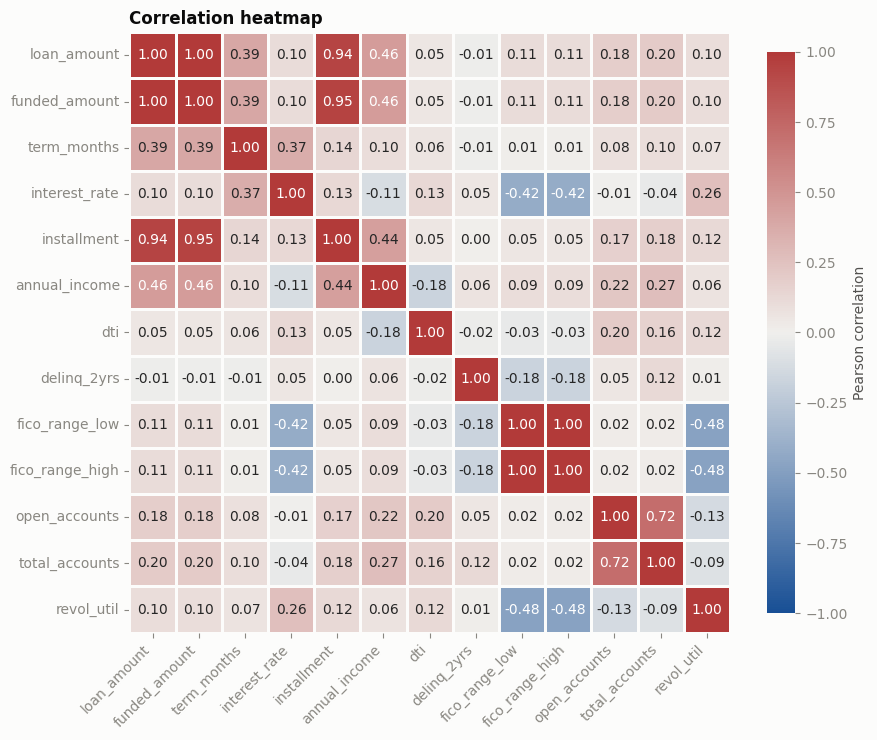

Strongest non-trivial pairwise correlation: loan_amount vs funded_amount = 1.00
Top 3 non-trivial pairs:
  loan_amount vs funded_amount: 1.00
  funded_amount vs installment: 0.95
  installment vs loan_amount: 0.94


In [4]:
fig, ax = plt.subplots(figsize=(9, 8))
plot_correlation_heatmap(sample_df, columns=NUMERIC_COLS, ax=ax)
plt.show()

import numpy as np

# fico_range_low/high move together almost by construction (fixed ~4pt spread) -
# exclude that pair so the "strongest correlation" reflects a genuine relationship.
DEGENERATE_PAIRS = {frozenset(["fico_range_low", "fico_range_high"])}

corr = sample_df[NUMERIC_COLS].corr()
corr_pairs = corr.where(~np.eye(len(corr), dtype=bool)).abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[[frozenset(idx) not in DEGENERATE_PAIRS for idx in corr_pairs.index]]
top_pair = corr_pairs.index[0]
top_val = corr.loc[top_pair]
print(f"Strongest non-trivial pairwise correlation: {top_pair[0]} vs {top_pair[1]} = {top_val:.2f}")
print("Top 3 non-trivial pairs:")
seen = set()
for idx, val in corr_pairs.items():
    key = frozenset(idx)
    if key in seen:
        continue
    seen.add(key)
    print(f"  {idx[0]} vs {idx[1]}: {corr.loc[idx]:.2f}")
    if len(seen) == 3:
        break

## Default rate by loan grade

,grade,total_loans,default_rate_pct
0,A,433027,3.28
1,B,663557,7.94
2,C,650053,13.20
3,D,324424,18.88
4,E,135639,26.69
5,F,41800,34.89
6,G,12168,38.07


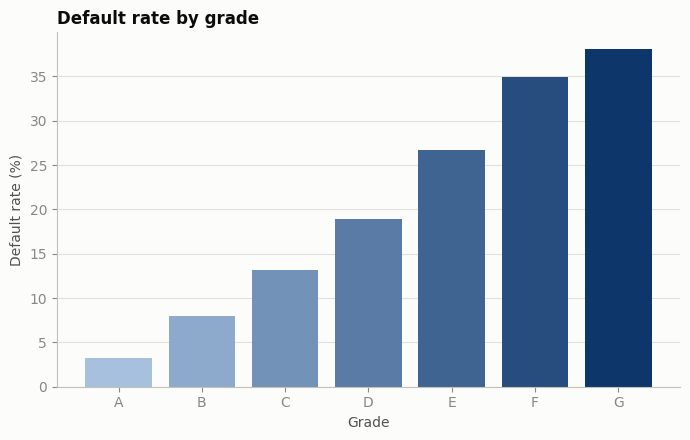

Grade A default rate: 3.28%
Grade G default rate: 38.07%
G is 11.6x more likely to default than A


In [5]:
by_grade = pd.read_sql("""
    SELECT grade, COUNT(*) AS total_loans,
           ROUND(100.0 * SUM(CASE WHEN loan_status IN ('Charged Off','Default') THEN 1 ELSE 0 END)
                 / COUNT(*), 2) AS default_rate_pct
    FROM finsight.loans GROUP BY grade ORDER BY grade;
""", engine)
display(by_grade)

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = sequential_shades(len(by_grade))
ax.bar(by_grade["grade"], by_grade["default_rate_pct"], color=colors)
ax.set_title("Default rate by grade", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Grade")
ax.set_ylabel("Default rate (%)")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

print(f"Grade A default rate: {by_grade.loc[by_grade.grade=='A','default_rate_pct'].iloc[0]}%")
print(f"Grade G default rate: {by_grade.loc[by_grade.grade=='G','default_rate_pct'].iloc[0]}%")
ratio = by_grade.loc[by_grade.grade=='G','default_rate_pct'].iloc[0] / by_grade.loc[by_grade.grade=='A','default_rate_pct'].iloc[0]
print(f"G is {ratio:.1f}x more likely to default than A")

## Default rate by loan purpose (top 10 by volume)

,purpose,total_loans,default_rate_pct
6,small_business,24689,18.84
9,moving,15403,14.47
0,debt_consolidation,1277877,12.94
5,medical,27488,12.41
3,other,139440,11.84
8,vacation,15525,11.23
4,major_purchase,50445,10.90
2,home_improvement,150457,10.35
1,credit_card,516971,9.68
7,car,24013,8.98


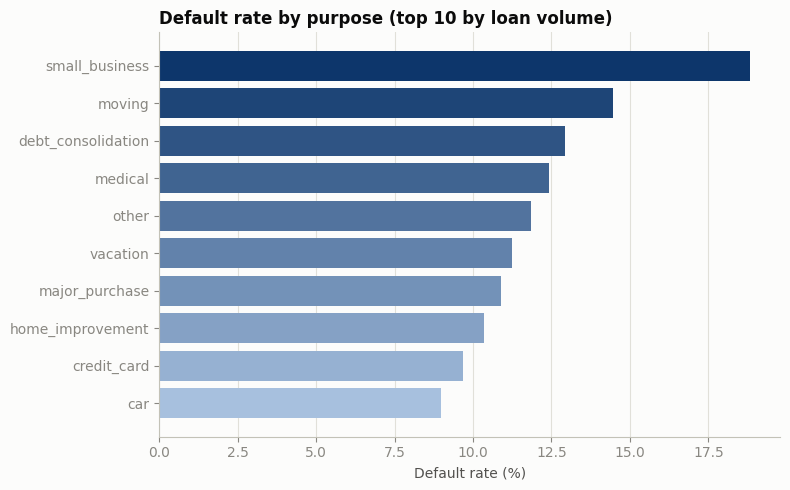

Portfolio-wide default rate: 11.92%
Highest-default purpose (top 10 by volume): small_business at 18.84% (24,689 loans)
Lowest-default purpose (top 10 by volume): car at 8.98% (24,013 loans)


In [6]:
by_purpose = pd.read_sql("""
    SELECT purpose, COUNT(*) AS total_loans,
           ROUND(100.0 * SUM(CASE WHEN loan_status IN ('Charged Off','Default') THEN 1 ELSE 0 END)
                 / COUNT(*), 2) AS default_rate_pct
    FROM finsight.loans GROUP BY purpose ORDER BY total_loans DESC LIMIT 10;
""", engine).sort_values("default_rate_pct", ascending=False)
display(by_purpose)

fig, ax = plt.subplots(figsize=(8, 5))
colors = sequential_shades(len(by_purpose))[::-1]
ax.barh(by_purpose["purpose"][::-1], by_purpose["default_rate_pct"][::-1], color=colors[::-1])
ax.set_title("Default rate by purpose (top 10 by loan volume)", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Default rate (%)")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

overall_default_rate = pd.read_sql("""
    SELECT ROUND(100.0 * SUM(CASE WHEN loan_status IN ('Charged Off','Default') THEN 1 ELSE 0 END)
                 / COUNT(*), 2) AS r FROM finsight.loans;
""", engine)["r"][0]
print(f"Portfolio-wide default rate: {overall_default_rate}%")
highest = by_purpose.iloc[0]
lowest = by_purpose.iloc[-1]
print(f"Highest-default purpose (top 10 by volume): {highest['purpose']} at {highest['default_rate_pct']}% ({highest['total_loans']:,} loans)")
print(f"Lowest-default purpose (top 10 by volume): {lowest['purpose']} at {lowest['default_rate_pct']}% ({lowest['total_loans']:,} loans)")

## Default rate by home ownership

In [7]:
by_home = pd.read_sql("""
    SELECT home_ownership, COUNT(*) AS total_loans,
           ROUND(100.0 * SUM(CASE WHEN loan_status IN ('Charged Off','Default') THEN 1 ELSE 0 END)
                 / COUNT(*), 2) AS default_rate_pct
    FROM finsight.loans GROUP BY home_ownership ORDER BY total_loans DESC;
""", engine)
display(by_home)

,home_ownership,total_loans,default_rate_pct
0,MORTGAGE,1111450,10.34
1,RENT,894929,13.91
2,OWN,253057,11.82
3,ANY,996,5.62
4,OTHER,182,20.88
5,NONE,54,14.81


## Key Insights

1. **Default rate climbs monotonically with grade, and steeply**: Grade A loans default at 3.28%, Grade G at 38.07% - G-grade borrowers are 11.6x more likely to default than A-grade. Grade alone is a strong, well-calibrated risk signal in this portfolio.
2. **Loan purpose matters even after controlling for volume**: among the 10 largest purpose categories, small_business loans default at 18.84% versus 8.98% for car loans (portfolio-wide average is 11.92%) - more than double, despite similar sample sizes (~24-25K loans each). Purpose-based pricing looks justified.
3. **Housing status is a secondary but real risk signal**: renters default at 13.91% versus 10.34% for mortgage holders (1.1M+ loans each) - a ~3.6 point gap that grade/FICO alone don't fully explain.
4. **Winsorization is visible and quantifiable**: capping at the 99th percentile clipped annual_income at $270,000 and loan_amount at $40,000 - about 1.0% and 1.4% of loans respectively sit exactly at these caps, showing up as a visible spike at the right edge of both histograms.
5. **dti has uncapped outlier contamination that visibly distorts its distribution**: the max dti value in the full 2.26M-row table is 999 (almost certainly a sentinel/data-entry value, not a real debt-to-income ratio), and 13,739 loans (0.61%) have dti > 50 while 2,561 (0.11%) exceed 100. Unlike annual_income/loan_amount, dti wasn't winsorized during cleaning per the original spec - worth capping before it's used as a model feature.
